# 04 — Rating-Progression

Frage: *Entwickelt sich das Rating der beiden Gruppen über Zeit unterschiedlich?*

Kennzahl: `rating_delta_from_start` pro Spieler × Periode (Median + IQR pro Gruppe).

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_view, load_query, apply_style, GROUP_PALETTE, GROUP_ORDER

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()

## Daten laden

In [4]:
df = load_view('v_rating_progression')
df['period'] = pd.to_datetime(df['period'])
df['std_rating'] = df['std_rating'].astype(float)
df['rating_delta_from_start'] = df['rating_delta_from_start'].astype(float)
print(df.shape)
df.head()

(97309, 5)


,analysis_group,fide_id,period,std_rating,rating_delta_from_start
0,male_control,105198,2010-01-01,2506.0,0.0
1,male_control,105198,2010-05-01,2497.0,-9.0
2,male_control,105198,2010-09-01,2490.0,-16.0
3,male_control,105198,2010-11-01,2482.0,-24.0
4,male_control,105198,2011-05-01,2467.0,-39.0


## Summary Start vs. aktuellster Stand

In [5]:
first = df.sort_values('period').groupby('fide_id').first()
last = df.sort_values('period').groupby('fide_id').last()
delta = last['std_rating'] - first['std_rating']
combined = first[['analysis_group']].assign(
    start_rating=first['std_rating'],
    end_rating=last['std_rating'],
    delta=delta,
)
combined.groupby('analysis_group').agg(
    n=('delta', 'count'),
    mean_start=('start_rating', 'mean'),
    mean_end=('end_rating', 'mean'),
    mean_delta=('delta', 'mean'),
    median_delta=('delta', 'median'),
).round(1)

,n,mean_start,mean_end,mean_delta,median_delta
analysis_group,,,,,
elite_2600,153,2235.6,2656.5,420.9,273.0
female_2200,4,1950.0,2248.0,298.0,316.0
female_top,43,2037.5,2463.5,426.1,412.0
male_control,435,2147.6,2470.5,322.9,130.0


## Rating-Delta über Zeit — Median + IQR pro Gruppe

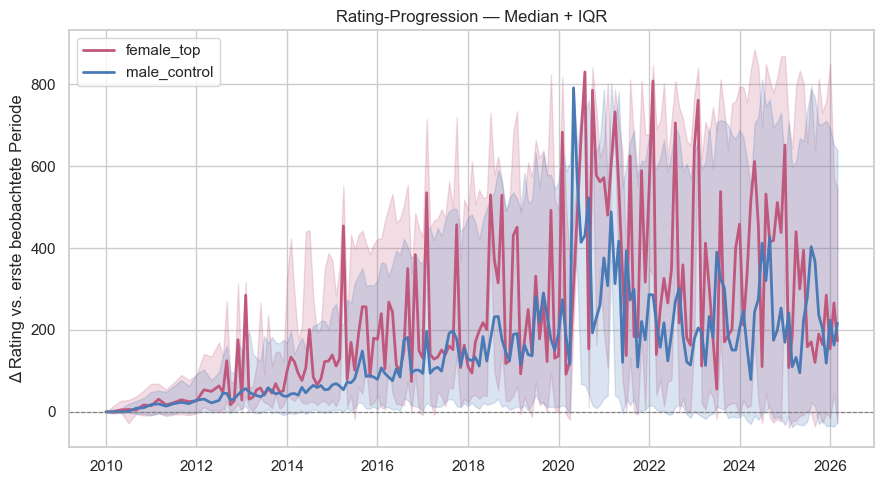

In [6]:
agg = (
    df.groupby(['analysis_group', 'period'])['rating_delta_from_start']
      .agg(['median',
            lambda s: s.quantile(0.25),
            lambda s: s.quantile(0.75)])
      .rename(columns={'<lambda_0>': 'q25', '<lambda_1>': 'q75'})
      .reset_index()
)
fig, ax = plt.subplots()
for grp in GROUP_ORDER:
    sub = agg[agg['analysis_group'] == grp]
    color = GROUP_PALETTE[grp]
    ax.plot(sub['period'], sub['median'], color=color, lw=2, label=grp)
    ax.fill_between(sub['period'], sub['q25'], sub['q75'], color=color, alpha=0.2)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Δ Rating vs. erste beobachtete Periode')
ax.set_title('Rating-Progression — Median + IQR')
ax.legend()
plt.tight_layout(); plt.show()

## Individueller Rating-Verlauf

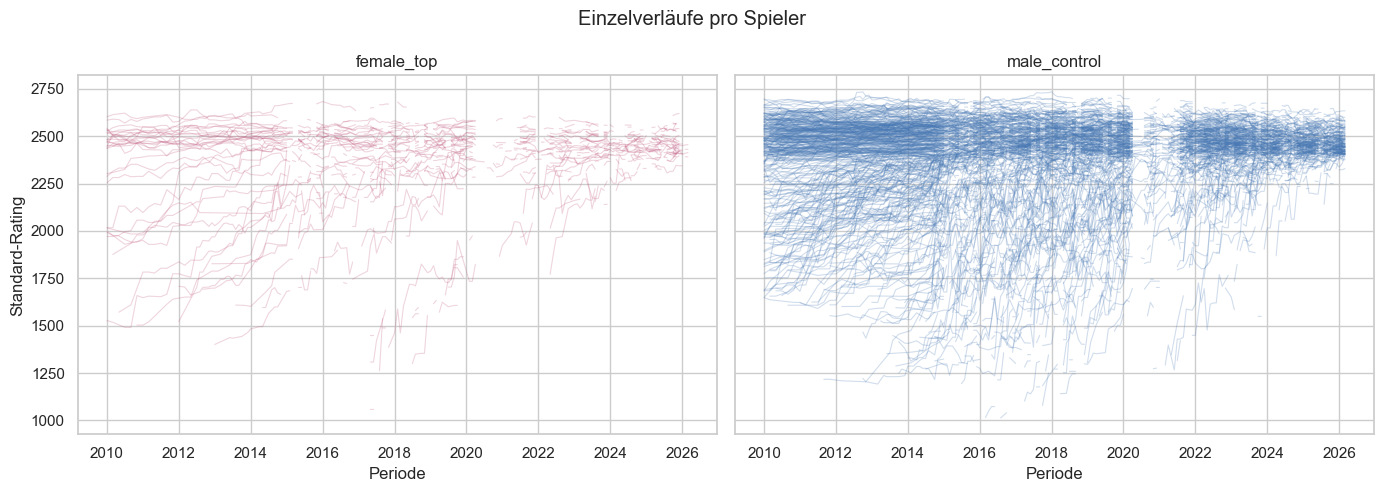

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, grp in zip(axes, GROUP_ORDER):
    sub = df[df['analysis_group'] == grp]
    for fid, g in sub.groupby('fide_id'):
        ax.plot(g['period'], g['std_rating'], color=GROUP_PALETTE[grp], alpha=0.25, lw=0.8)
    ax.set_title(grp)
    ax.set_xlabel('Periode')
axes[0].set_ylabel('Standard-Rating')
plt.suptitle('Einzelverläufe pro Spieler')
plt.tight_layout(); plt.show()